# Implement Hough Transform using CUDA.

In [11]:
!wget -O image.jpg "https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/bsds/BSDS300/html/images/plain/normal/color/126007.jpg"

--2026-06-01 10:36:39--  https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/bsds/BSDS300/html/images/plain/normal/color/126007.jpg
Resolving www2.eecs.berkeley.edu (www2.eecs.berkeley.edu)... 128.32.244.190
Connecting to www2.eecs.berkeley.edu (www2.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24067 (24K) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg           100%[===================>]  23.50K   139KB/s    in 0.2s    

2026-06-01 10:36:40 (139 KB/s) - ‘image.jpg’ saved [24067/24067]



Image Shape: (321, 481)
Detected Line:
rho = 193
theta = 74


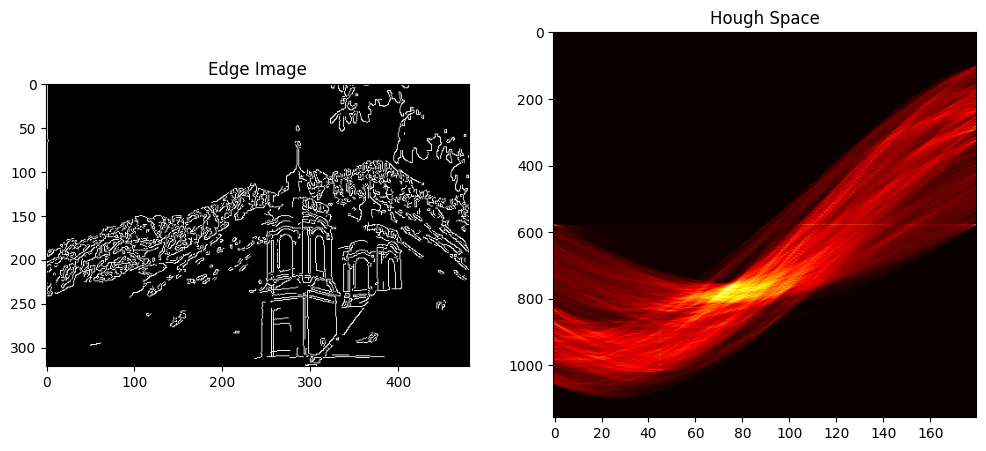

In [12]:
import cv2
import numpy as np
from numba import cuda
import math
import matplotlib.pyplot as plt

# ==========================================
# Load BSDS500 Image
# ==========================================

image_path = "/content/image.jpg"

img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found")

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# ==========================================
# Edge Detection
# ==========================================

edges = cv2.Canny(
    gray,
    100,
    200
)

height, width = edges.shape

print("Image Shape:", edges.shape)

# ==========================================
# Hough Parameters
# ==========================================

rho_max = int(
    np.sqrt(width**2 + height**2)
)

theta_steps = 180

accumulator = np.zeros(
    (2 * rho_max, theta_steps),
    dtype=np.int32
)

# ==========================================
# CUDA Kernel
# ==========================================

@cuda.jit
def hough_transform(
        edge_img,
        accumulator,
        width,
        height,
        rho_max,
        theta_steps):

    x, y = cuda.grid(2)

    if x < width and y < height:

        if edge_img[y, x] > 0:

            for t in range(theta_steps):

                theta = math.radians(t)

                rho = int(
                    x * math.cos(theta)
                    +
                    y * math.sin(theta)
                )

                rho_idx = rho + rho_max

                cuda.atomic.add(
                    accumulator,
                    (rho_idx, t),
                    1
                )

# ==========================================
# GPU Memory
# ==========================================

d_edges = cuda.to_device(edges)

d_accumulator = cuda.to_device(
    accumulator
)

threads_per_block = (16, 16)

blocks_per_grid = (
    (width + 15) // 16,
    (height + 15) // 16
)

# ==========================================
# Launch Kernel
# ==========================================

hough_transform[
    blocks_per_grid,
    threads_per_block
](
    d_edges,
    d_accumulator,
    width,
    height,
    rho_max,
    theta_steps
)

cuda.synchronize()

# ==========================================
# Copy Result Back
# ==========================================

accumulator = (
    d_accumulator.copy_to_host()
)

# ==========================================
# Find Strongest Line
# ==========================================

rho_idx, theta_idx = np.unravel_index(
    np.argmax(accumulator),
    accumulator.shape
)

rho = rho_idx - rho_max
theta = np.deg2rad(theta_idx)

print("Detected Line:")
print("rho =", rho)
print("theta =", theta_idx)

# ==========================================
# Display Results
# ==========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(edges, cmap="gray")
plt.title("Edge Image")

plt.subplot(1,2,2)
plt.imshow(
    accumulator,
    cmap="hot",
    aspect="auto"
)
plt.title("Hough Space")

plt.show()